# W10 robustness and measurement-noise ceiling

## tl;dr

B4의 B1 대비 작은 RMSE 이득은 세 bootstrap seed, inclusion threshold 10/20/30,
1k–10k variable-gene filter, 극단 sensitivity 제거에서 양의 95% CI를 유지했다.
Leave-one-lineage-out 평균 이득은 0.00051이나 CI가 0을 포함했다. 더 중요하게,
조건당 정확히 20개 세포로 맞춘 5회 재표집에서는 이득이 모두 음수였다.
Raw cells의 split-half Δ로 추정한 full-target noise floor는 RMSE 0.279였고
split-half PCC는 0.236에 불과했다. 따라서 원 코호트의 0.53% 개선은 계산적으로
재현되지만 sampling support에 민감하며 강한 개인화 증거가 아니다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cell_count_matrix.csv").exists()
)


In [2]:
summary = json.loads((root / "results/logs/robustness_summary.json").read_text())
validation = json.loads((root / "results/logs/robustness_validation.json").read_text())
metrics = pd.read_csv(root / "results/tables/robustness_metrics.csv")
noise = pd.read_csv(root / "results/tables/noise_ceiling_by_line.csv")
subsampling = pd.read_csv(root / "results/tables/subsampling_metrics.csv")
conclusions = pd.read_csv(root / "results/tables/robustness_conclusions.csv")

display(pd.DataFrame({
    "metric": ["robustness rows", "split-half rows", "subsampling rows",
               "mean target noise floor", "mean split-half PCC"],
    "value": [summary["robustness_rows"], summary["noise_rows"],
              summary["subsampling_rows"],
              summary["mean_full_target_noise_floor_approx"],
              summary["mean_split_half_pcc"]],
}))
assert validation["status"] == "passed"
assert validation["threshold_cohort_sizes"] == {
    "min_cells_10": 97, "min_cells_20": 94, "min_cells_30": 82
}


,metric,value
0,robustness rows,69.000000
1,split-half rows,470.000000
2,subsampling rows,470.000000
3,mean target noise floor,0.279028
4,mean split-half PCC,0.236373


## Context & Methods

### Key Assumptions

- 모든 모델 평가는 cell-line held-out이며 fixed PC20/alpha100 B4를 쓴다.
- threshold 10/20/30은 time-matched DMSO24와 Tram24가 모두 기준을 만족한
  97/94/82-line 코호트에서 다시 split한다.
- variable genes는 각 training fold control에서만 1k/3k/5k/10k를 선택한다.
- leave-one-lineage-out은 한 Disease lineage 전체를 test로 둔다.
- sensitivity 양끝 10% 제거는 기존 OOF prediction의 사후 강건성 분석이다.
- equal-cell 분석은 각 조건에서 line당 20개 raw cell을 without replacement로 뽑아
  5회 pseudobulk와 모델 평가를 처음부터 반복한다.
- noise ceiling은 같은 line/condition 세포를 두 반으로 나눈 response Δ끼리 비교한다.
  Half-to-half RMSE/2를 full-target sampling noise의 근사값으로 보고 인과적·절대적
  상한으로 과대해석하지 않는다.

## Results

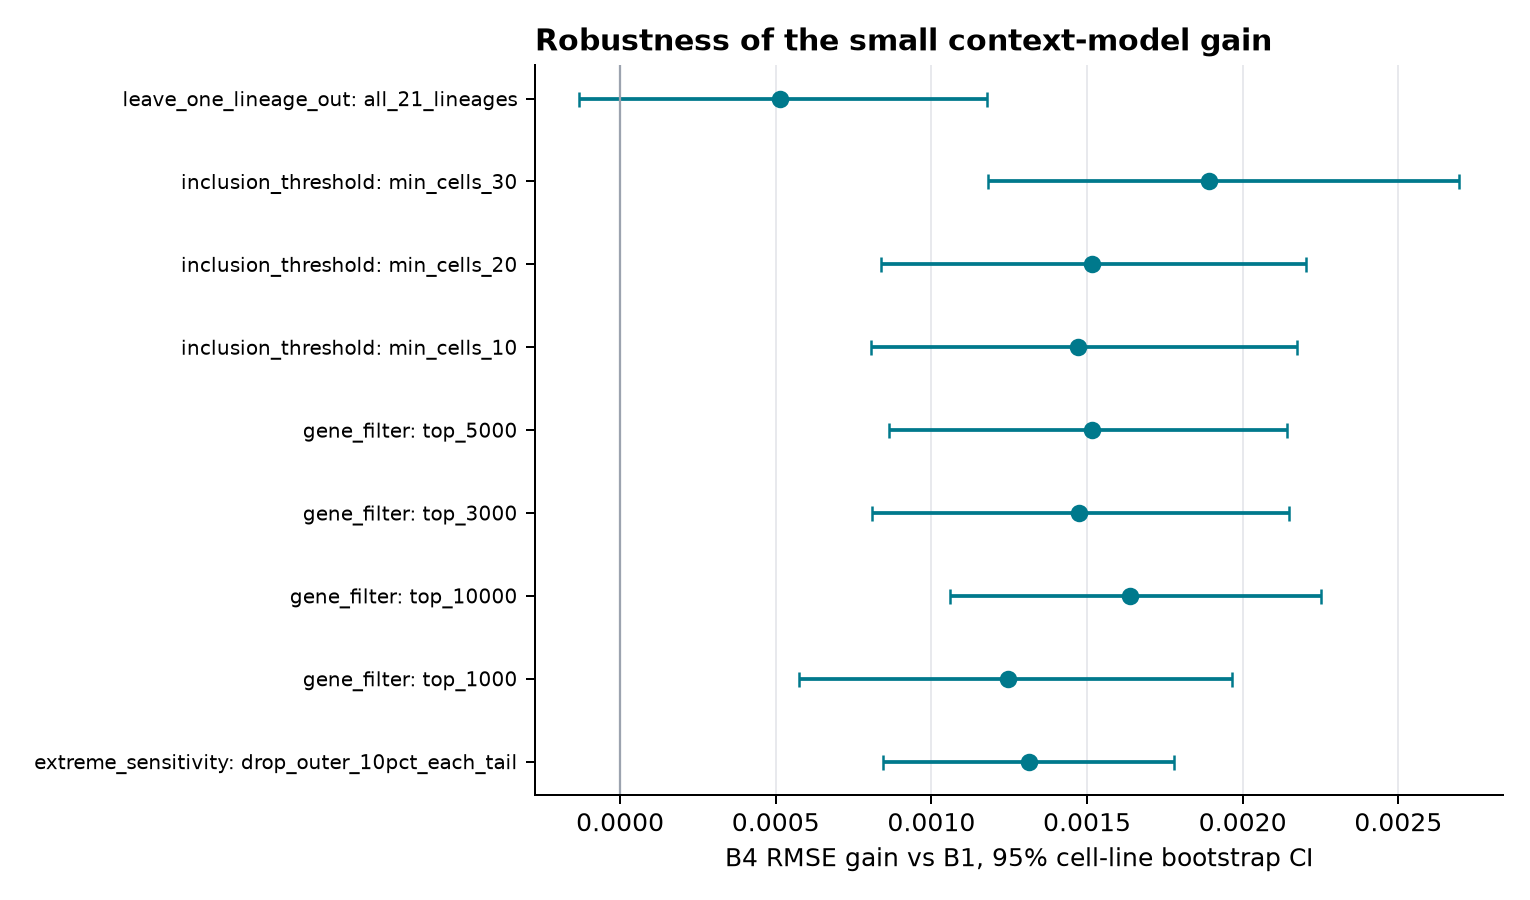

,analysis,variant,estimate,ci95_low,ci95_high,n
0,cell_line_bootstrap,seed_20260827,0.001715,0.001180,0.002246,94
1,cell_line_bootstrap,seed_20260828,0.001715,0.001192,0.002250,94
2,cell_line_bootstrap,seed_20260829,0.001715,0.001189,0.002252,94
4,gene_filter,top_1000,0.001246,0.000574,0.001965,94
8,gene_filter,top_3000,0.001474,0.000810,0.002149,94
12,gene_filter,top_5000,0.001517,0.000864,0.002143,94
16,gene_filter,top_10000,0.001637,0.001061,0.002250,94
20,inclusion_threshold,min_cells_10,0.001470,0.000806,0.002174,97
24,inclusion_threshold,min_cells_20,0.001517,0.000839,0.002205,94
28,inclusion_threshold,min_cells_30,0.001892,0.001183,0.002695,82


,conclusion,status,evidence
0,B4 gain over B1 is positive in the frozen split,robust,three bootstrap seeds have CI above zero
1,B4 gain survives inclusion thresholds 10/20/30,robust,gain range 0.001470 to 0.001892
2,B4 gain survives variable-gene filters,robust,gain range 0.001246 to 0.001637
3,B4 gain survives equal-20-cell subsampling,sensitive,positive repeats 0/5
4,B4 gain under leave-one-lineage-out,inconclusive,"LOLO gain 0.000514, 95% CI -0.000132 to 0.001178"
5,Absolute error is close to a nonzero measureme...,limitation,split-half-derived full-target floor 0.2790


In [3]:
display(Image(filename=str(root / "results/figures/robustness_summary.png")))
display(metrics.loc[
    metrics["metric"].eq("rmse_gain_vs_b1")
    & metrics["analysis"].isin([
        "cell_line_bootstrap", "inclusion_threshold", "gene_filter",
        "extreme_sensitivity", "leave_one_lineage_out", "response_rank"
    ]),
    ["analysis", "variant", "estimate", "ci95_low", "ci95_high", "n"]
])
display(conclusions)


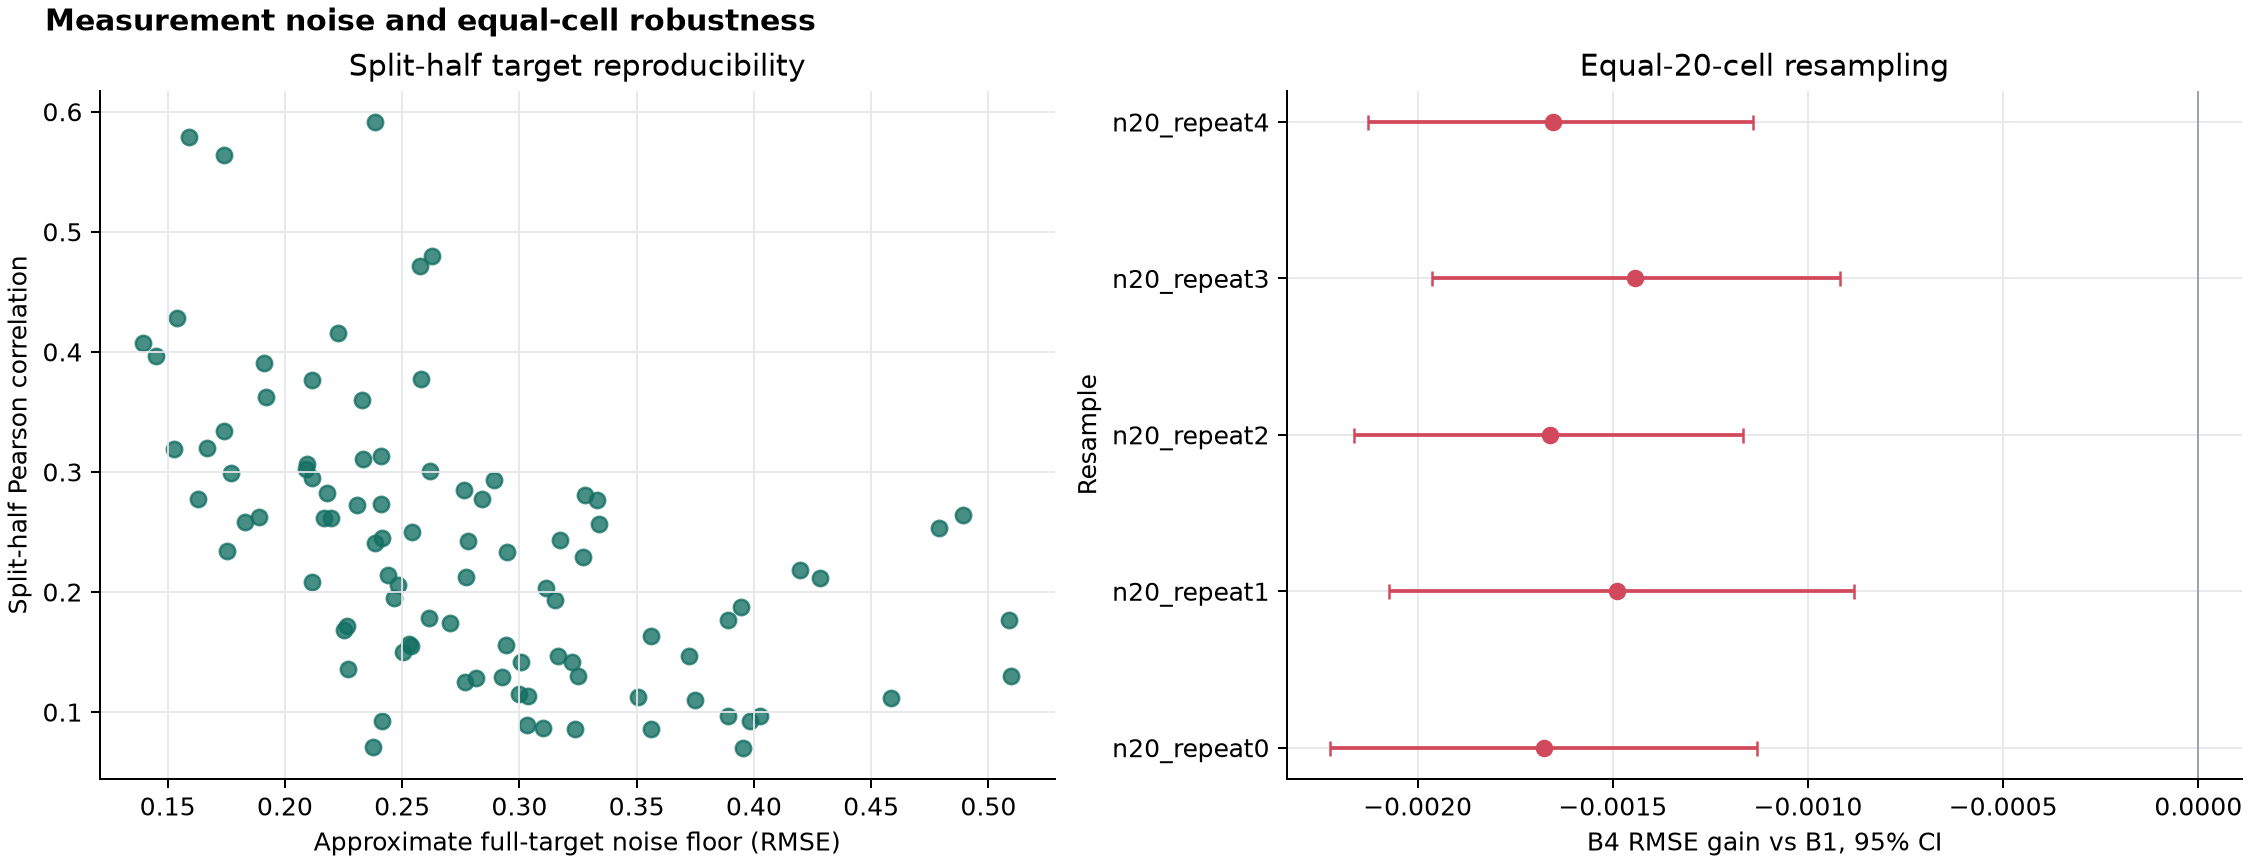

,analysis,variant,metric,estimate,ci95_low,ci95_high,n
33,cell_subsampling,n20_repeat0,b1_rmse,0.552425,0.538186,0.566760,94
34,cell_subsampling,n20_repeat0,b4_rmse,0.554102,0.540008,0.568065,94
35,cell_subsampling,n20_repeat0,rmse_gain_vs_b1,-0.001677,-0.002223,-0.001131,94
36,cell_subsampling,n20_repeat0,b4_pcc,0.273416,0.262010,0.285546,94
37,cell_subsampling,n20_repeat0,b4_spearman,0.222891,0.213129,0.233332,94
38,cell_subsampling,n20_repeat1,b1_rmse,0.554914,0.541568,0.568442,94
39,cell_subsampling,n20_repeat1,b4_rmse,0.556404,0.543180,0.569757,94
40,cell_subsampling,n20_repeat1,rmse_gain_vs_b1,-0.001490,-0.002073,-0.000883,94
41,cell_subsampling,n20_repeat1,b4_pcc,0.278917,0.266404,0.291278,94
42,cell_subsampling,n20_repeat1,b4_spearman,0.229230,0.218790,0.239658,94


,full_target_noise_floor_approx,split_half_pcc
count,94.000000,94.000000
mean,0.279028,0.236373
std,0.084371,0.115042
min,0.139644,0.070340
25%,0.223410,0.146848
50%,0.261603,0.231145
75%,0.323189,0.294769
max,0.509734,0.591455


In [4]:
display(Image(filename=str(root / "results/figures/noise_ceiling.png")))
display(metrics.loc[metrics["analysis"].isin(["cell_subsampling", "split_half_noise"]), [
    "analysis", "variant", "metric", "estimate", "ci95_low", "ci95_high", "n"
]])
display(noise.groupby("cell_line")[[
    "full_target_noise_floor_approx", "split_half_pcc"
]].mean().describe())


## Takeaways

- **동결 결과는 계산적으로 안정적**: bootstrap seed와 threshold, gene filter,
  sensitivity outlier 제거에서는 B4−B1 이득의 방향과 CI가 유지된다.
- **lineage 외삽은 불확실**: LOLO 평균은 양수지만 CI −0.00013–0.00118로 0을 포함한다.
- **sampling에는 취약**: 20-cell 균등 재표집에서 gain은 매회 −0.00144∼−0.00168이고
  각 CI도 0 아래다. 원 데이터의 line별 cell-count 차이가 결과 안정성에 중요하다.
- **target noise가 큼**: noise-floor 근사 0.279는 B4 RMSE 0.322의 큰 부분이며,
  split-half PCC 0.236은 개별-line 전체 gene Δ가 낮은 세포 수에서 불안정함을 뜻한다.
- **rank 결론 유지**: rank 2–50 low-rank 변형은 모두 B1보다 낫지만 W7의 B4를
  넘는 고정 변형은 없다.

최종 주장은 “baseline context의 작은 신호가 검출된다”로 제한하고,
“강한 개인화 예측” 또는 “새 lineage에 확실히 일반화”라고 주장하지 않는다.